In [35]:
import json
import re
import yaml
import pandas as pd
import matplotlib.pyplot as plt

CSV_PERSON_FILE_SIZE = 880941057      # bytes
JSON_PERSON_FILE_SIZE = 1300941057    # bytes

def shorten_query(q):
    q = re.sub(r"\s+INTO\s+\w+", "", q, flags=re.IGNORECASE)
    q = re.sub(r'VARSIZED\("([^"]+)"\)', r'"\1"', q)
    q = re.sub(r'INT32\((\d+)\)', r'\1', q)
    q = re.sub(r'FLOAT64\(([\d.]+)\)', r'\1', q)
    return re.sub(r'\s+', ' ', q).strip()

def load_query_text(query_file):
    with open(query_file) as f:
        return yaml.safe_load(f)["query"]

def get_file_size(suite_name):
    if "json" in suite_name.lower():
        return JSON_PERSON_FILE_SIZE
    return CSV_PERSON_FILE_SIZE

def load_suite(filepath, suite_name, query_dir):
    with open(filepath) as f:
        data = json.load(f)
    file_size = get_file_size(suite_name)
    rows = []
    for r in data:
        if r.get("state") != "Stopped":
            continue
        exec_time = (r["stop_time_ms"] - r["start_time_ms"]) / 1000.0
        if exec_time <= 0:
            continue
        query_file = r["query_file"]
        query_text = shorten_query(load_query_text(query_file))
        rows.append({
            "suite": suite_name,
            "query": query_text,
            "threads": r["threads_number"],
            "exec_time_s": exec_time,
            "throughput_MBs": file_size / exec_time / (1024 * 1024),
        })
    return rows

rows = []
rows += load_suite("results/baseline_results_1776374217.json", "CSV baseline", "queries")
rows += load_suite("results/optimized_results_1776375022.json", "CSV optimized", "queries")
rows += load_suite("results/baseline-json_results_1776348348.json", "JSON baseline", "queries-json")
rows += load_suite("results/optimized-json_results_1776349781.json", "JSON optimized", "queries-json")
df = pd.DataFrame(rows)
print(f"Records: {len(df)}")
print(f"Suites: {sorted(df['suite'].unique())}")
print(f"Threads: {sorted(df['threads'].unique())}")
print(f"Queries: {sorted(df['query'].unique())}")
df

Records: 840
Suites: ['CSV baseline', 'CSV optimized', 'JSON baseline', 'JSON optimized']
Threads: [np.int64(2), np.int64(4), np.int64(8), np.int64(16), np.int64(32), np.int64(48), np.int64(64)]
Queries: ['SELECT * FROM PERSON', 'SELECT EXTRA FROM PERSON', 'SELECT ID FROM PERSON WHERE CITY == "redmond" AND STATE == "wy"']


,suite,query,threads,exec_time_s,throughput_MBs
0,CSV baseline,SELECT EXTRA FROM PERSON,2,4.020,208.987776
1,CSV baseline,SELECT EXTRA FROM PERSON,2,3.985,210.823302
2,CSV baseline,SELECT EXTRA FROM PERSON,2,4.281,196.246405
3,CSV baseline,SELECT EXTRA FROM PERSON,2,3.905,215.142346
4,CSV baseline,SELECT EXTRA FROM PERSON,2,3.778,222.374500
...,...,...,...,...,...
835,JSON optimized,SELECT * FROM PERSON,64,1.063,1167.144001
836,JSON optimized,SELECT * FROM PERSON,64,0.998,1243.160394
837,JSON optimized,SELECT * FROM PERSON,64,1.059,1171.552477
838,JSON optimized,SELECT * FROM PERSON,64,1.018,1218.736811


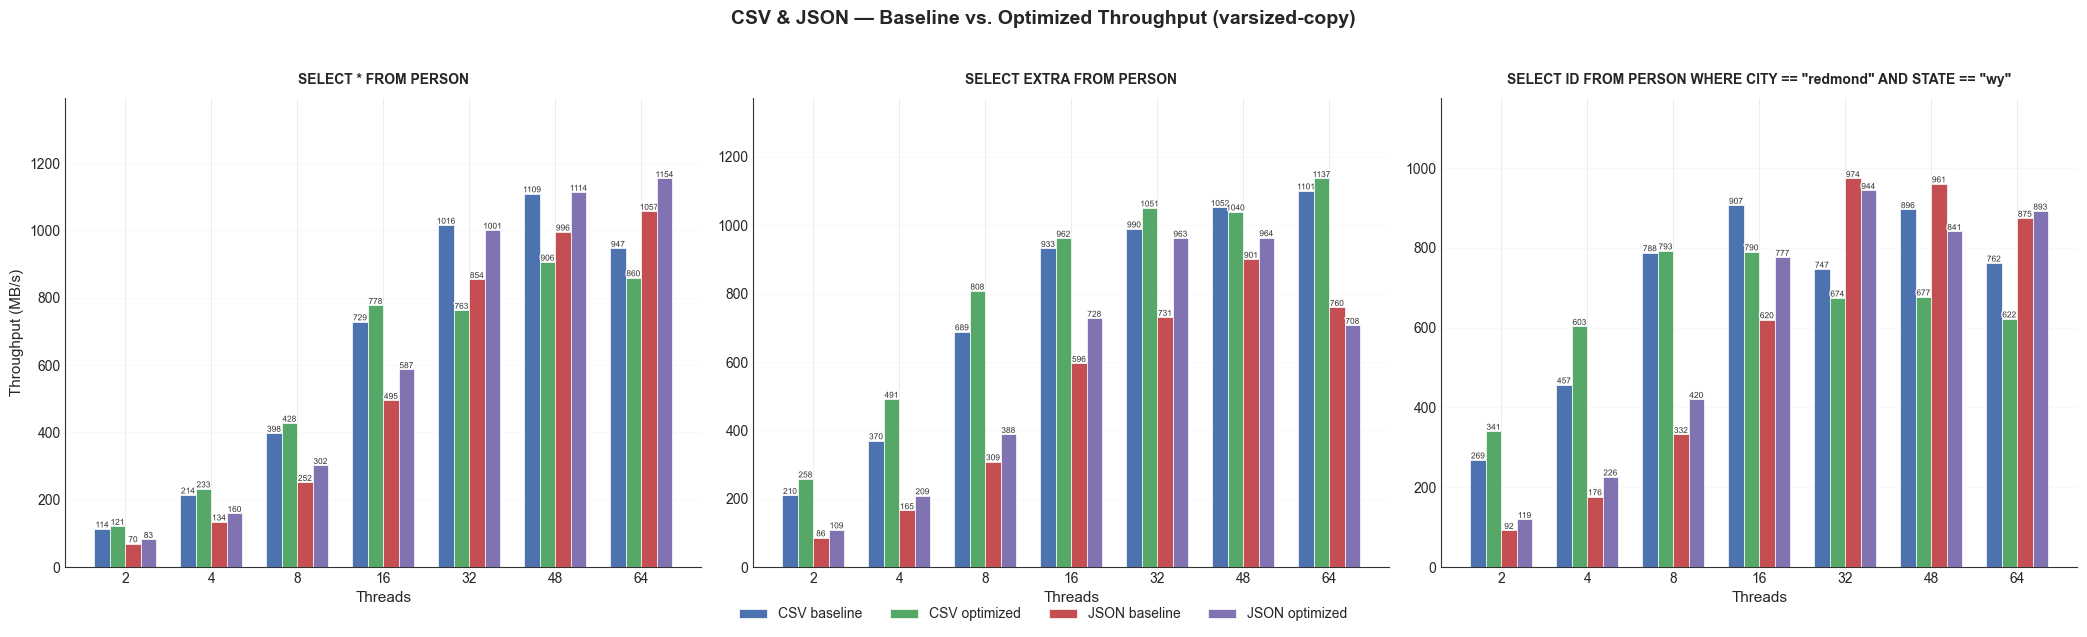

In [36]:
# Grouped bar chart: suites per thread count, one subplot per query
import numpy as np
import matplotlib.patheffects as pe

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.size": 11,
    "axes.edgecolor": "#333333",
    "axes.linewidth": 0.8,
})

queries = sorted(df["query"].unique())
suites = ["CSV baseline", "CSV optimized", "JSON baseline", "JSON optimized"]
suite_colors = {
    "CSV baseline":  "#4C72B0",
    "CSV optimized": "#55A868",
    "JSON baseline": "#C44E52",
    "JSON optimized": "#8172B2",
}
thread_counts = sorted(df["threads"].unique())
n_suites = len(suites)
bar_width = 0.18

n_queries = len(queries)
n_cols = min(3, n_queries)
n_rows = (n_queries + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(7 * n_cols, 6 * n_rows),
                          sharey=False, squeeze=False)

x = np.arange(len(thread_counts))

for idx, q in enumerate(queries):
    row, col = divmod(idx, n_cols)
    ax = axes[row, col]
    for j, suite in enumerate(suites):
        s_data = df[(df["query"] == q) & (df["suite"] == suite)]
        vals = s_data.groupby("threads")["throughput_MBs"].median().reindex(thread_counts)
        offset = (j - (n_suites - 1) / 2) * bar_width
        bars = ax.bar(x + offset, vals.values, bar_width, label=suite,
                       color=suite_colors[suite], edgecolor="white", linewidth=0.5,
                       zorder=3)
        for bar in bars:
            h = bar.get_height()
            if h is not None and not np.isnan(h):
                txt = ax.text(bar.get_x() + bar.get_width() / 2, h + 1,
                              f"{h:.0f}", ha="center", va="bottom", fontsize=6,
                              color="#333333", fontweight="medium")
                txt.set_path_effects([pe.withStroke(linewidth=2, foreground="white")])

    ax.set_xlabel("Threads", fontsize=11, fontweight="medium")
    ax.set_ylabel("Throughput (MB/s)" if col == 0 else "", fontsize=11, fontweight="medium")
    ax.set_title(q, fontsize=10, fontweight="bold", pad=10)
    ax.set_xticks(x)
    ax.set_xticklabels(thread_counts)
    ax.set_ylim(0, ax.get_ylim()[1] * 1.15)
    ax.tick_params(axis="both", which="major", labelsize=10)
    ax.grid(True, alpha=0.25, axis="y", linestyle="--", zorder=0)
    ax.set_axisbelow(True)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

# Hide unused subplots
for idx in range(n_queries, n_rows * n_cols):
    row, col = divmod(idx, n_cols)
    axes[row, col].set_visible(False)

# Single shared legend at the bottom
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=n_suites, fontsize=10,
           framealpha=0.9, edgecolor="#cccccc", bbox_to_anchor=(0.5, -0.02))

fig.suptitle("CSV & JSON — Baseline vs. Optimized Throughput (varsized-copy)",
             fontsize=14, fontweight="bold", y=1.02)
fig.tight_layout()
plt.show()

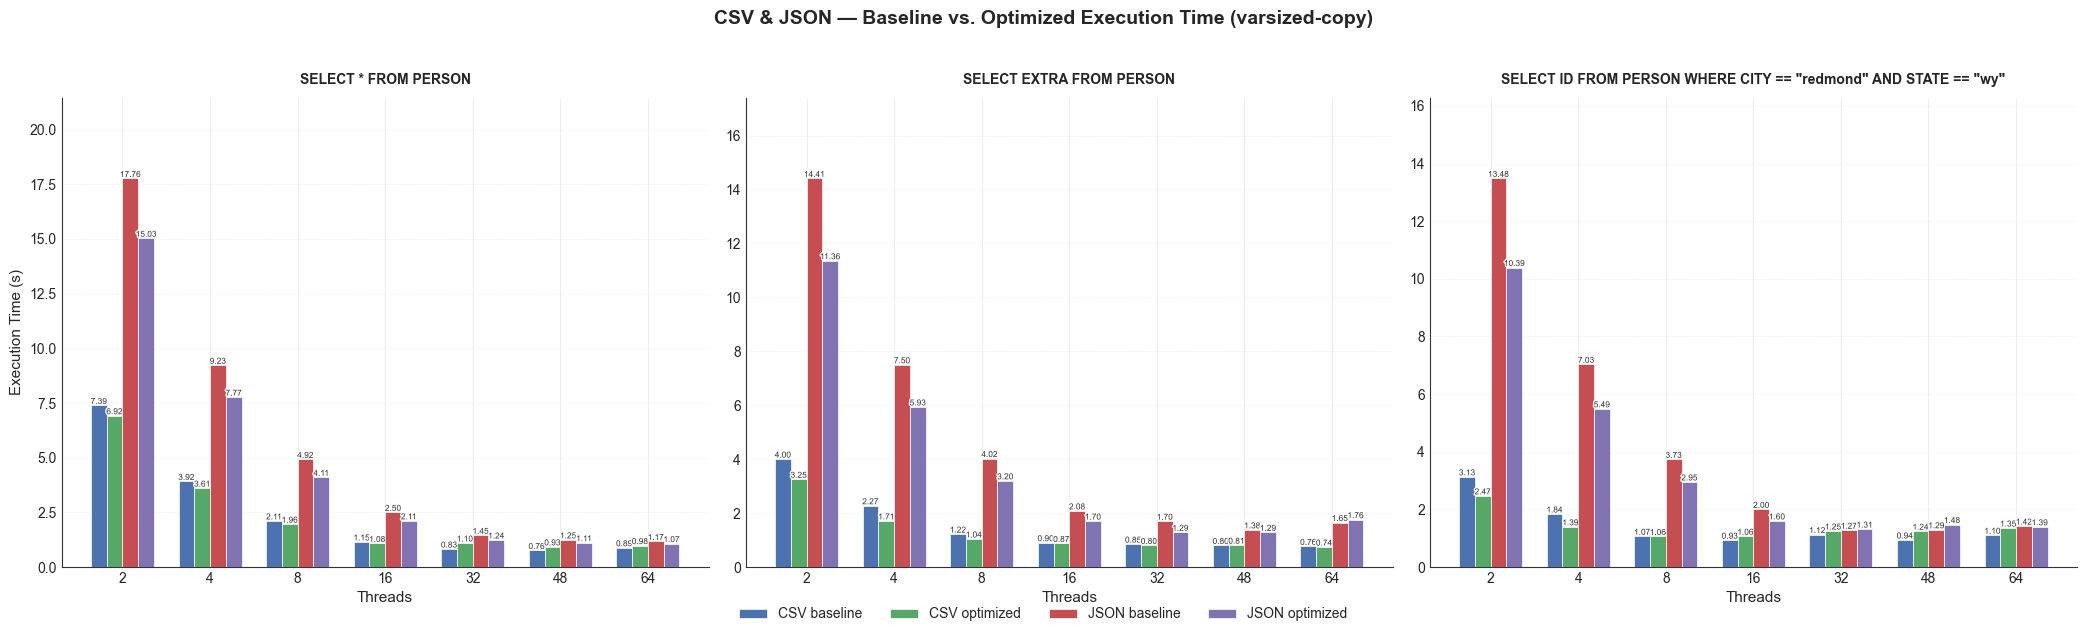

In [37]:
# Grouped bar chart: execution time per thread count, one subplot per query
import numpy as np
import matplotlib.patheffects as pe

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.size": 11,
    "axes.edgecolor": "#333333",
    "axes.linewidth": 0.8,
})

queries = sorted(df["query"].unique())
suites = ["CSV baseline", "CSV optimized", "JSON baseline", "JSON optimized"]
suite_colors = {
    "CSV baseline":  "#4C72B0",
    "CSV optimized": "#55A868",
    "JSON baseline": "#C44E52",
    "JSON optimized": "#8172B2",
}
thread_counts = sorted(df["threads"].unique())
n_suites = len(suites)
bar_width = 0.18

n_queries = len(queries)
n_cols = min(3, n_queries)
n_rows = (n_queries + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(7 * n_cols, 6 * n_rows),
                          sharey=False, squeeze=False)

x = np.arange(len(thread_counts))

for idx, q in enumerate(queries):
    row, col = divmod(idx, n_cols)
    ax = axes[row, col]
    for j, suite in enumerate(suites):
        s_data = df[(df["query"] == q) & (df["suite"] == suite)]
        vals = s_data.groupby("threads")["exec_time_s"].median().reindex(thread_counts)
        offset = (j - (n_suites - 1) / 2) * bar_width
        bars = ax.bar(x + offset, vals.values, bar_width, label=suite,
                       color=suite_colors[suite], edgecolor="white", linewidth=0.5,
                       zorder=3)
        for bar in bars:
            h = bar.get_height()
            if h is not None and not np.isnan(h):
                txt = ax.text(bar.get_x() + bar.get_width() / 2, h + 0.02,
                              f"{h:.2f}", ha="center", va="bottom", fontsize=6,
                              color="#333333", fontweight="medium")
                txt.set_path_effects([pe.withStroke(linewidth=2, foreground="white")])

    ax.set_xlabel("Threads", fontsize=11, fontweight="medium")
    ax.set_ylabel("Execution Time (s)" if col == 0 else "", fontsize=11, fontweight="medium")
    ax.set_title(q, fontsize=10, fontweight="bold", pad=10)
    ax.set_xticks(x)
    ax.set_xticklabels(thread_counts)
    ax.set_ylim(0, ax.get_ylim()[1] * 1.15)
    ax.tick_params(axis="both", which="major", labelsize=10)
    ax.grid(True, alpha=0.25, axis="y", linestyle="--", zorder=0)
    ax.set_axisbelow(True)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

# Hide unused subplots
for idx in range(n_queries, n_rows * n_cols):
    row, col = divmod(idx, n_cols)
    axes[row, col].set_visible(False)

# Single shared legend at the bottom
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=n_suites, fontsize=10,
           framealpha=0.9, edgecolor="#cccccc", bbox_to_anchor=(0.5, -0.02))

fig.suptitle("CSV & JSON — Baseline vs. Optimized Execution Time (varsized-copy)",
             fontsize=14, fontweight="bold", y=1.02)
fig.tight_layout()
plt.show()

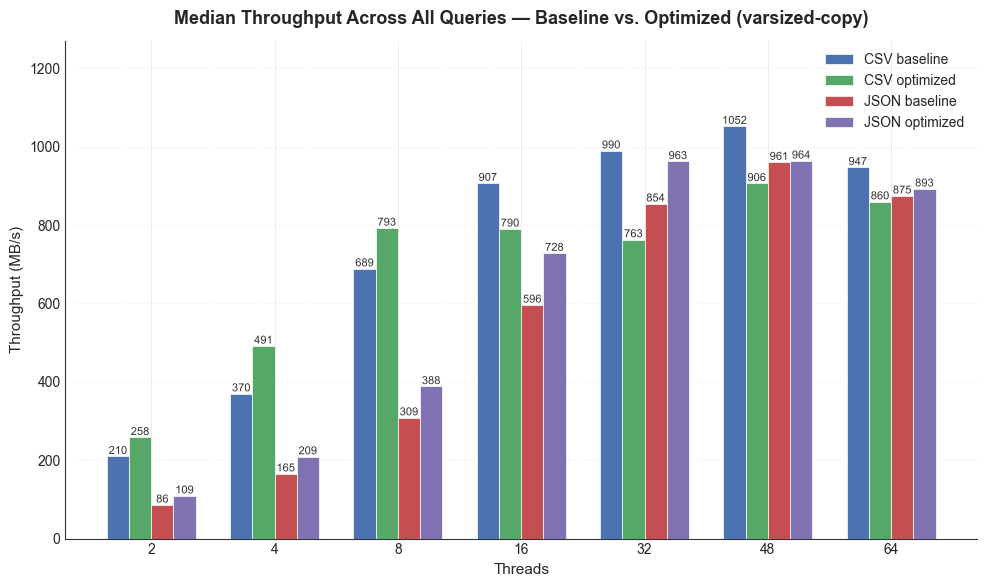

In [38]:
# Median throughput across all queries per suite & thread count
import numpy as np
import matplotlib.patheffects as pe

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.size": 11,
    "axes.edgecolor": "#333333",
    "axes.linewidth": 0.8,
})

suites = ["CSV baseline", "CSV optimized", "JSON baseline", "JSON optimized"]
suite_colors = {
    "CSV baseline":  "#4C72B0",
    "CSV optimized": "#55A868",
    "JSON baseline": "#C44E52",
    "JSON optimized": "#8172B2",
}
thread_counts = sorted(df["threads"].unique())
n_suites = len(suites)
bar_width = 0.18
x = np.arange(len(thread_counts))

# For each (suite, threads) pair, first get per-query median, then median across queries
median_across = (
    df.groupby(["suite", "threads", "query"])["throughput_MBs"]
    .median()
    .groupby(level=["suite", "threads"])
    .median()
)

fig, ax = plt.subplots(figsize=(10, 6))

for j, suite in enumerate(suites):
    if suite not in median_across.index.get_level_values("suite"):
        continue
    vals = median_across.loc[suite].reindex(thread_counts)
    offset = (j - (n_suites - 1) / 2) * bar_width
    bars = ax.bar(x + offset, vals.values, bar_width, label=suite,
                  color=suite_colors[suite], edgecolor="white", linewidth=0.5, zorder=3)
    for bar in bars:
        h = bar.get_height()
        if h is not None and not np.isnan(h):
            txt = ax.text(bar.get_x() + bar.get_width() / 2, h + 1,
                          f"{h:.0f}", ha="center", va="bottom", fontsize=8,
                          color="#333333", fontweight="medium")
            txt.set_path_effects([pe.withStroke(linewidth=2, foreground="white")])

ax.set_xlabel("Threads", fontsize=11, fontweight="medium")
ax.set_ylabel("Throughput (MB/s)", fontsize=11, fontweight="medium")
ax.set_title("Median Throughput Across All Queries — Baseline vs. Optimized (varsized-copy)",
             fontsize=13, fontweight="bold", pad=12)
ax.set_xticks(x)
ax.set_xticklabels(thread_counts)
ax.set_ylim(0, ax.get_ylim()[1] * 1.15)
ax.tick_params(axis="both", which="major", labelsize=10)
ax.grid(True, alpha=0.25, axis="y", linestyle="--", zorder=0)
ax.set_axisbelow(True)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.legend(fontsize=10, framealpha=0.9, edgecolor="#cccccc")

fig.tight_layout()
plt.show()

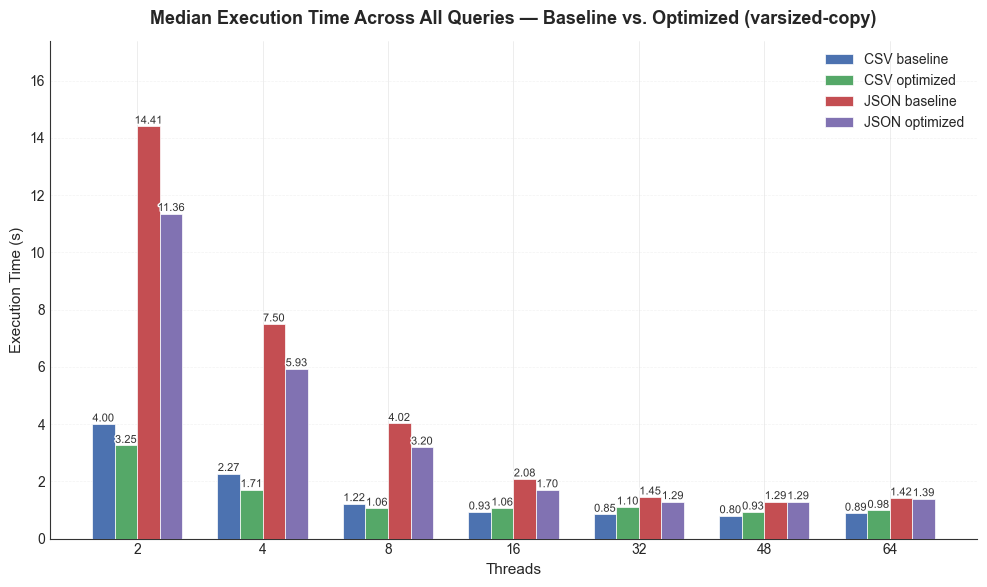

In [39]:
# Median execution time across all queries per suite & thread count
import numpy as np
import matplotlib.patheffects as pe

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.size": 11,
    "axes.edgecolor": "#333333",
    "axes.linewidth": 0.8,
})

suites = ["CSV baseline", "CSV optimized", "JSON baseline", "JSON optimized"]
suite_colors = {
    "CSV baseline":  "#4C72B0",
    "CSV optimized": "#55A868",
    "JSON baseline": "#C44E52",
    "JSON optimized": "#8172B2",
}
thread_counts = sorted(df["threads"].unique())
n_suites = len(suites)
bar_width = 0.18
x = np.arange(len(thread_counts))

# For each (suite, threads) pair, first get per-query median, then median across queries
median_across = (
    df.groupby(["suite", "threads", "query"])["exec_time_s"]
    .median()
    .groupby(level=["suite", "threads"])
    .median()
)

fig, ax = plt.subplots(figsize=(10, 6))

for j, suite in enumerate(suites):
    if suite not in median_across.index.get_level_values("suite"):
        continue
    vals = median_across.loc[suite].reindex(thread_counts)
    offset = (j - (n_suites - 1) / 2) * bar_width
    bars = ax.bar(x + offset, vals.values, bar_width, label=suite,
                  color=suite_colors[suite], edgecolor="white", linewidth=0.5, zorder=3)
    for bar in bars:
        h = bar.get_height()
        if h is not None and not np.isnan(h):
            txt = ax.text(bar.get_x() + bar.get_width() / 2, h + 0.02,
                          f"{h:.2f}", ha="center", va="bottom", fontsize=8,
                          color="#333333", fontweight="medium")
            txt.set_path_effects([pe.withStroke(linewidth=2, foreground="white")])

ax.set_xlabel("Threads", fontsize=11, fontweight="medium")
ax.set_ylabel("Execution Time (s)", fontsize=11, fontweight="medium")
ax.set_title("Median Execution Time Across All Queries — Baseline vs. Optimized (varsized-copy)",
             fontsize=13, fontweight="bold", pad=12)
ax.set_xticks(x)
ax.set_xticklabels(thread_counts)
ax.set_ylim(0, ax.get_ylim()[1] * 1.15)
ax.tick_params(axis="both", which="major", labelsize=10)
ax.grid(True, alpha=0.25, axis="y", linestyle="--", zorder=0)
ax.set_axisbelow(True)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.legend(fontsize=10, framealpha=0.9, edgecolor="#cccccc")

fig.tight_layout()
plt.show()

In [40]:
# Summary table: throughput (MB/s) all 4 suites
all_suites = [s for s in ["CSV baseline", "CSV optimized", "JSON baseline", "JSON optimized"] if s in df["suite"].unique()]
pivot = df.pivot_table(index=["query", "threads"], columns="suite", values="throughput_MBs", aggfunc="median")
pivot = pivot[[s for s in all_suites if s in pivot.columns]]
if "CSV baseline" in pivot.columns and "CSV optimized" in pivot.columns:
    pivot["CSV speedup"] = pivot["CSV optimized"] / pivot["CSV baseline"]
if "JSON baseline" in pivot.columns and "JSON optimized" in pivot.columns:
    pivot["JSON speedup"] = pivot["JSON optimized"] / pivot["JSON baseline"]
pivot.round(2)

suite                                                       CSV baseline  \
query                                              threads                 
SELECT * FROM PERSON                               2              113.67   
                                                   4              214.42   
                                                   8              397.98   
                                                   16             728.97   
                                                   32            1015.95   
                                                   48            1109.30   
                                                   64             947.20   
SELECT EXTRA FROM PERSON                           2              209.91   
                                                   4              369.87   
                                                   8              688.86   
                                                   16             932.58   
                                                   32             989.75   
                                                   48            1052.39   
                                                   64            1101.01   
SELECT ID FROM PERSON WHERE CITY == "redmond" A... 2              268.63   
                                                   4              456.85   
                                                   8              788.16   
                                                   16             906.97   
                                                   32             746.93   
                                                   48             896.18   
                                                   64             762.19   

suite                                                       CSV optimized  \
query                                              threads                  
SELECT * FROM PERSON                               2               121.40   
                                                   4               232.73   
                                                   8               427.98   
                                                   16              777.54   
                                                   32              763.06   
                                                   48              906.42   
                                                   64              859.91   
SELECT EXTRA FROM PERSON                           2               258.27   
                                                   4               491.46   
                                                   8               807.93   
                                                   16              962.38   
                                                   32             1050.89   
                                                   48             1039.55   
                                                   64             1136.85   
SELECT ID FROM PERSON WHERE CITY == "redmond" A... 2               340.69   
                                                   4               603.33   
                                                   8               792.71   
                                                   16              790.33   
                                                   32              674.49   
                                                   48              677.37   
                                                   64              622.08   

suite                                                       JSON baseline  \
query                                              threads                  
SELECT * FROM PERSON                               2                69.85   
                                                   4               134.46   
                                                   8               251.91   
                                                   16              495.38   
                 